In [52]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

In [45]:
mic_df = pd.read_csv("./data/mic_data.csv")
mic_df = mic_df.set_index('Genome ID')
mic_df

,amikacin,cefotaxime,ceftazidime,cefuroxime,ciprofloxacin,gentamicin,imipenem,meropenem,piperacillin/tazobactam
Genome ID,,,,,,,,,
5.621042e+02,4.0,NaN,NaN,NaN,3.0,2.0,0.0,-3.058894,NaN
5.621042e+02,4.0,NaN,NaN,NaN,3.0,2.0,0.0,-3.058894,NaN
5.621042e+02,4.0,NaN,NaN,NaN,3.0,4.0,0.0,-3.058894,NaN
5.621042e+02,4.0,NaN,NaN,NaN,-2.0,5.0,0.0,-3.058894,NaN
5.621042e+02,4.0,NaN,NaN,NaN,3.0,2.0,0.0,-3.058894,NaN
...,...,...,...,...,...,...,...,...,...
1.438694e+06,1.0,4.0,4.0,NaN,-2.0,4.0,0.0,-2.000000,NaN
1.438695e+06,1.0,6.0,6.0,NaN,2.0,4.0,1.0,-2.000000,NaN
1.438696e+06,1.0,3.0,4.0,NaN,-2.0,0.0,0.0,-2.000000,NaN


In [46]:
len(mic_df.columns)

9

In [ ]:
# Function for distribution of MIC values per antibiotic
def MICDistribution(X):
    n_antibiotics = len(X.columns)
    n_cols = 3
    n_rows = (n_antibiotics + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(10, n_rows * 3),
        sharey=False,
        sharex=True
    )
    axes = axes.flatten()

    for i, antibiotic in enumerate(X.columns):
        values = X[antibiotic].dropna()
        axes[i].hist(values, bins=15, edgecolor='black', color='steelblue')
        axes[i].set_title(antibiotic, fontsize=7, pad=2)
        axes[i].tick_params(labelsize=6)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fig.text(0.5, 0.02, 'log2 MIC', ha='center', fontsize=11)
    fig.text(0.02, 0.5, 'Count', va='center', rotation='vertical', fontsize=11)

    plt.suptitle('Distribution of log2 MIC Values per Antibiotic', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

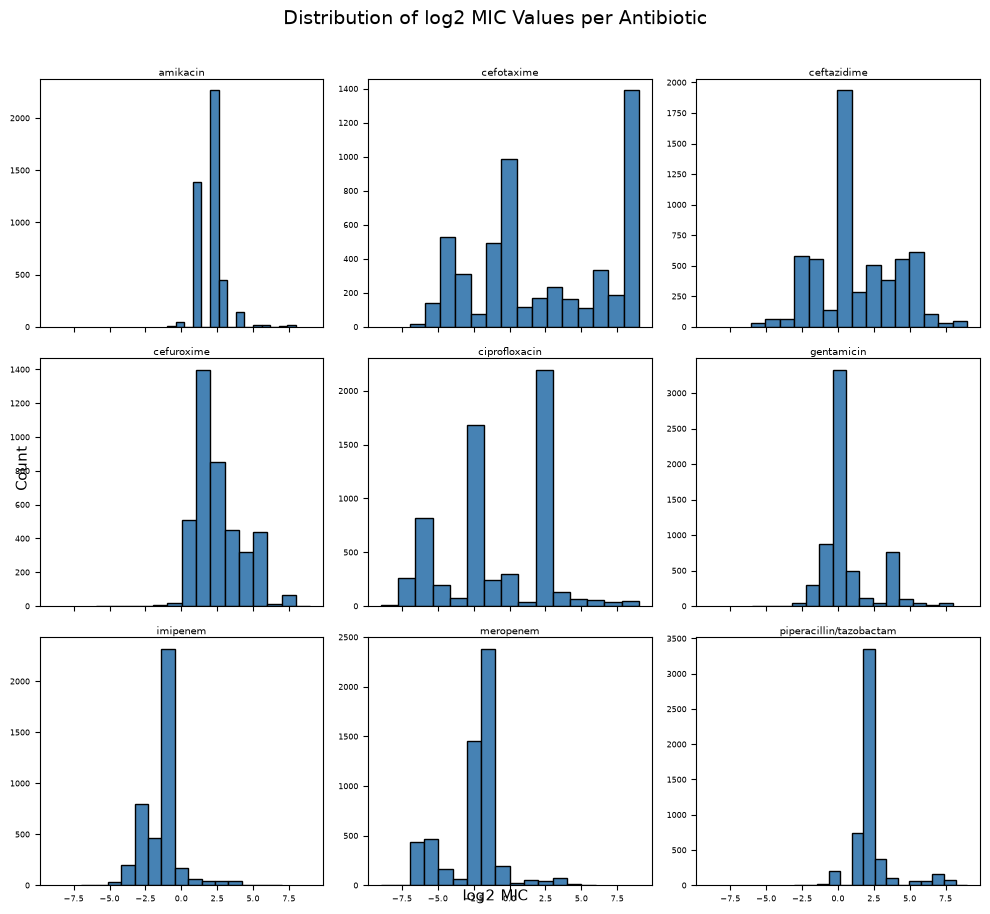

In [54]:
# Distribution of pre-imputation data
MICDistribution(mic_df)

In [55]:
# Function for correlation matrix
def MICCorrelation(X):
    corr_matrix = X.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, 
                annot=True, 
                fmt='.2f', 
                cmap='RdYlGn_r', 
                center=0, 
                square=True, 
                linewidths=0.5, 
                annot_kws={'size': 7}
    )

    plt.title('Correlation Between Antibiotic MIC Values')
    plt.tight_layout()
    plt.show()

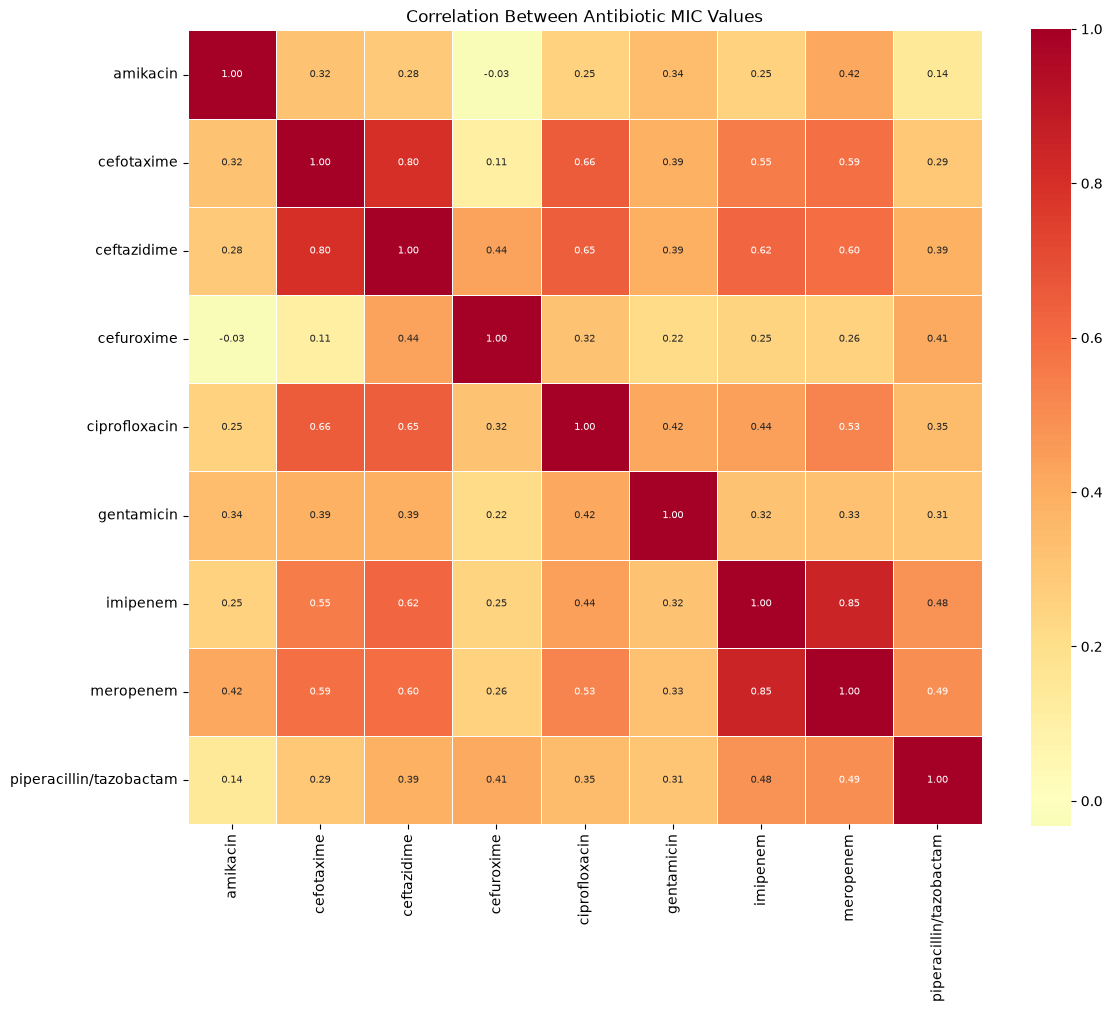

In [56]:
# Correlation matrix of pre-imputation data
MICCorrelation(mic_df)

In [57]:
# Data inputation
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(mic_df)
X_imputed = pd.DataFrame(X_imputed, index=mic_df.index, columns=mic_df.columns)
X_imputed

,amikacin,cefotaxime,ceftazidime,cefuroxime,ciprofloxacin,gentamicin,imipenem,meropenem,piperacillin/tazobactam
Genome ID,,,,,,,,,
5.621042e+02,4.0,2.0,5.2,1.8,3.0,2.0,0.0,-3.058894,2.0
5.621042e+02,4.0,2.0,5.2,1.8,3.0,2.0,0.0,-3.058894,2.0
5.621042e+02,4.0,6.0,4.8,4.0,3.0,4.0,0.0,-3.058894,6.6
5.621042e+02,4.0,6.0,2.2,2.6,-2.0,5.0,0.0,-3.058894,2.0
5.621042e+02,4.0,2.0,5.2,1.8,3.0,2.0,0.0,-3.058894,2.0
...,...,...,...,...,...,...,...,...,...
1.438694e+06,1.0,4.0,4.0,5.8,-2.0,4.0,0.0,-2.000000,2.0
1.438695e+06,1.0,6.0,6.0,5.0,2.0,4.0,1.0,-2.000000,4.8
1.438696e+06,1.0,3.0,4.0,5.8,-2.0,0.0,0.0,-2.000000,2.0


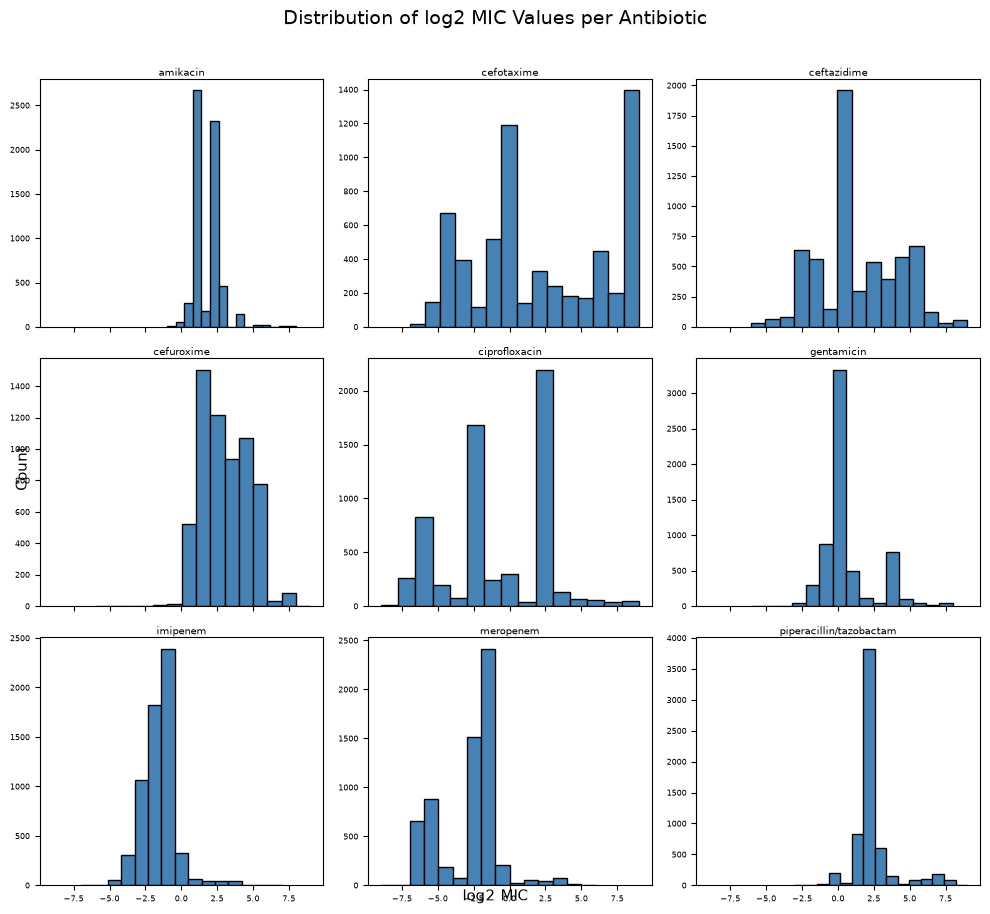

In [58]:
# Distribution of imputed data
MICDistribution(X_imputed)

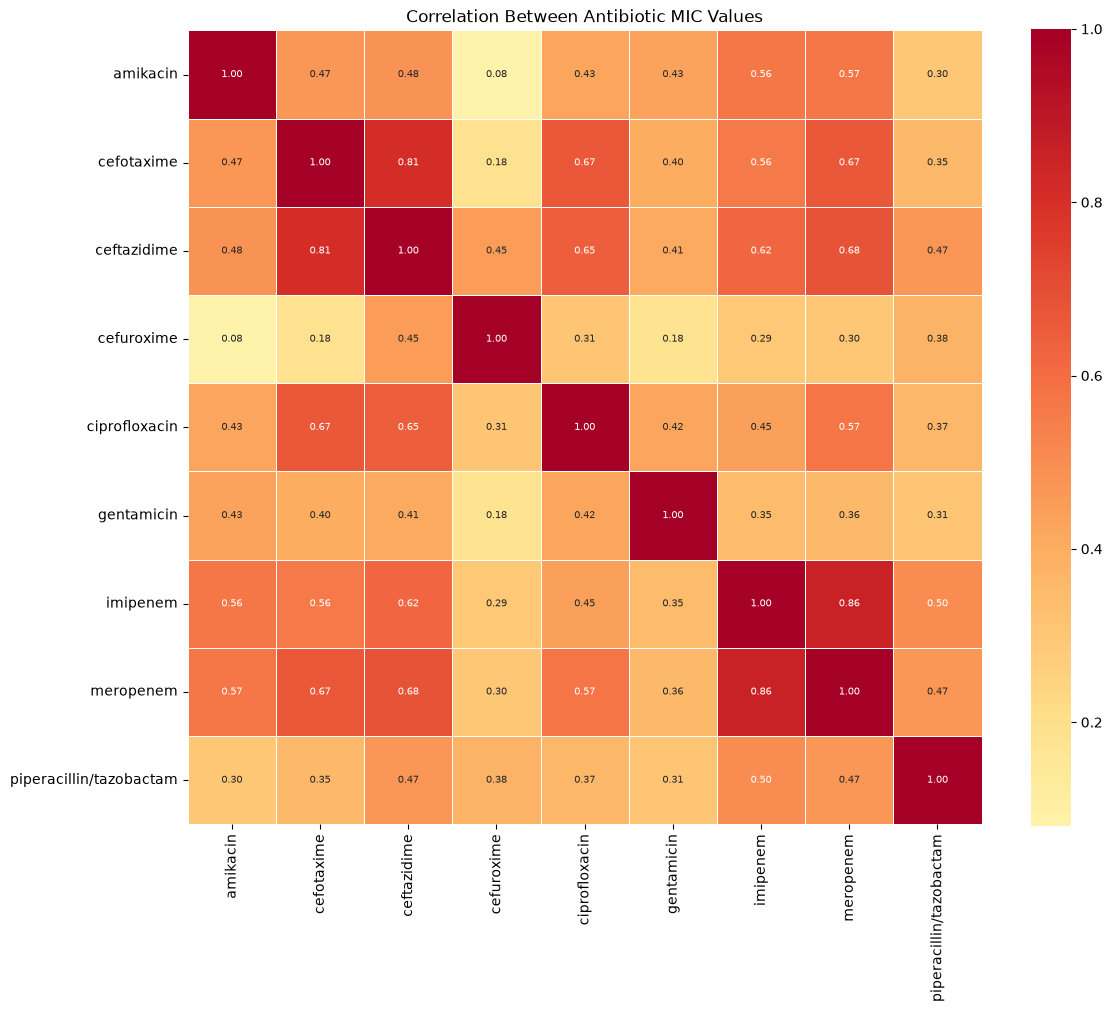

In [59]:
# Correlation matrix of imputed data
MICCorrelation(X_imputed)

In [60]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [61]:
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)